In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt

In [3]:
# Load datasets
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val   = np.load("X_val.npy")
y_val   = np.load("y_val.npy")
X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")

# Load scaler
scaler = joblib.load("scaler.pkl")

In [4]:
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Shapes:
X_train: (30277, 48, 1) y_train: (30277, 4)
X_val  : (7563, 48, 1) y_val  : (7563, 4)
X_test : (5997, 48, 1) y_test : (5997, 4)


In [5]:
# callbacks
model = Sequential()

# LSTM layer
model.add(LSTM(units=64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))

# Dense output layer (multi-step forecast)
model.add(Dense(y_train.shape[1]))

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,156 (67.02 KB)

 Trainable params: 17,156 (67.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
checkpoint  = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True)

In [7]:
# train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0229 - mae: 0.1070

474/474 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.0228 - mae: 0.1069 - val_loss: 0.0050 - val_mae: 0.0532
Epoch 2/100
472/474 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0054 - mae: 0.0556

474/474 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0054 - mae: 0.0555 - val_loss: 0.0035 - val_mae: 0.0431
Epoch 3/100
473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0040 - mae: 0.0473

474/474 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - loss: 0.0040 - mae: 0.0473 - val_loss: 0.0030 - val_mae: 0.0392
Epoch 4/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0035 - mae: 0.0434

474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0035 - mae: 0.0434 - val_loss: 0.0027 - val_mae: 0.0368
Epoch 5/100
472/474 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0032 - mae: 0.0409

...

474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0025 - mae: 0.0352 - val_loss: 0.0023 - val_mae: 0.0331
Epoch 18/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0025 - mae: 0.0352 - val_loss: 0.0023 - val_mae: 0.0331
Epoch 19/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0026 - mae: 0.0355 - val_loss: 0.0023 - val_mae: 0.0335
Epoch 20/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0025 - mae: 0.0351

474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0025 - mae: 0.0351 - val_loss: 0.0023 - val_mae: 0.0330
Epoch 21/100
473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0025 - mae: 0.0353

474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0025 - mae: 0.0353 - val_loss: 0.0023 - val_mae: 0.0332
Epoch 22/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0025 - mae: 0.0355 - val_loss: 0.0023 - val_mae: 0.0334
Epoch 23/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0025 - mae: 0.0353 - val_loss: 0.0023 - val_mae: 0.0332
Epoch 24/100
472/474 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0025 - mae: 0.0354

474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0025 - mae: 0.0354 - val_loss: 0.0023 - val_mae: 0.0329
Epoch 25/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0025 - mae: 0.0349 - val_loss: 0.0023 - val_mae: 0.0336
Epoch 26/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0025 - mae: 0.0349 - val_loss: 0.0023 - val_mae: 0.0338
Epoch 27/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 0.0025 - mae: 0.0353 - val_loss: 0.0023 - val_mae: 0.0332
Epoch 28/100
472/474 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0025 - mae: 0.0350

474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0025 - mae: 0.0350 - val_loss: 0.0023 - val_mae: 0.0327
Epoch 29/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0025 - mae: 0.0350 - val_loss: 0.0023 - val_mae: 0.0327
Epoch 30/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0025 - mae: 0.0351 - val_loss: 0.0023 - val_mae: 0.0330
Epoch 31/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0025 - mae: 0.0352 - val_loss: 0.0023 - val_mae: 0.0336
Epoch 32/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0025 - mae: 0.0352 - val_loss: 0.0023 - val_mae: 0.0331
Epoch 33/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0025 - mae: 0.0350 - val_loss: 0.0024 - val_mae: 0.0361
Epoch 34/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0025 - mae: 0.0355 - val_loss: 0.0023 - val_mae: 0.0333
Epoch 35/100
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0024 - mae: 0.0346 - val_loss: 0.0023 - val_mae: 0.0337
Epoch 36/100
474/474 ━━━━━━━━━━━━━━━━

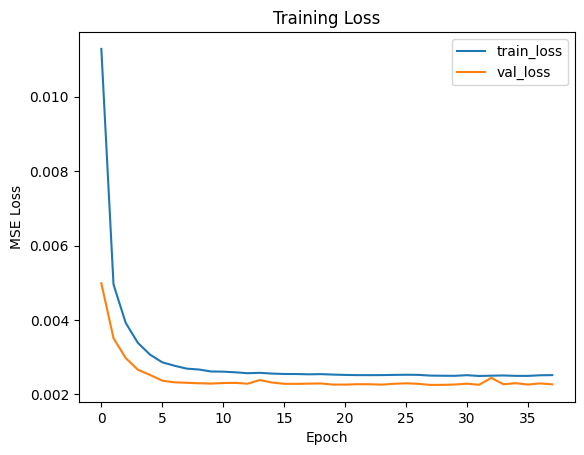

In [9]:
# Plot Predictions
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [18]:
# Evaluate on Test Set
y_pred_scaled = model.predict(X_test)

# Inverse-transform to glucose values
# Only transform the first feature (glucose)
def inverse_transform_sequence(y_scaled, scaler):
    y_scaled_flat = y_scaled.flatten().reshape(-1,1)
    y_real = scaler.inverse_transform(y_scaled_flat)
    return y_real.reshape(y_scaled.shape)

y_pred = inverse_transform_sequence(y_pred_scaled, scaler)
y_real = inverse_transform_sequence(y_test, scaler)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [12]:
# y_real and y_pred are inverse-transformed (mg/dL)
n_steps = y_real.shape[1]

for step in range(n_steps):
    rmse_step = np.sqrt(np.mean((y_real[:, step] - y_pred[:, step])**2))
    mae_step  = np.mean(np.abs(y_real[:, step] - y_pred[:, step]))
    mape_step = np.mean(np.abs((y_real[:, step] - y_pred[:, step]) / y_real[:, step])) * 100
    accuracy_step = 100 - mape_step

    print(f"Step {step+1} ({15*step + 15} min ahead):")
    print(f"  RMSE : {rmse_step:.2f} mg/dL")
    print(f"  MAE  : {mae_step:.2f} mg/dL")
    print(f"  MAPE : {mape_step:.2f} %")
    print(f"  Approx. accuracy: {accuracy_step:.2f} %\n")

Step 1 (15 min ahead):
  RMSE : 7.54 mg/dL
  MAE  : 5.51 mg/dL
  MAPE : 3.49 %
  Approx. accuracy: 96.51 %

Step 2 (30 min ahead):
  RMSE : 17.67 mg/dL
  MAE  : 13.08 mg/dL
  MAPE : 8.37 %
  Approx. accuracy: 91.63 %

Step 3 (45 min ahead):
  RMSE : 26.03 mg/dL
  MAE  : 19.40 mg/dL
  MAPE : 12.63 %
  Approx. accuracy: 87.37 %

Step 4 (60 min ahead):
  RMSE : 32.52 mg/dL
  MAE  : 24.69 mg/dL
  MAPE : 16.47 %
  Approx. accuracy: 83.53 %



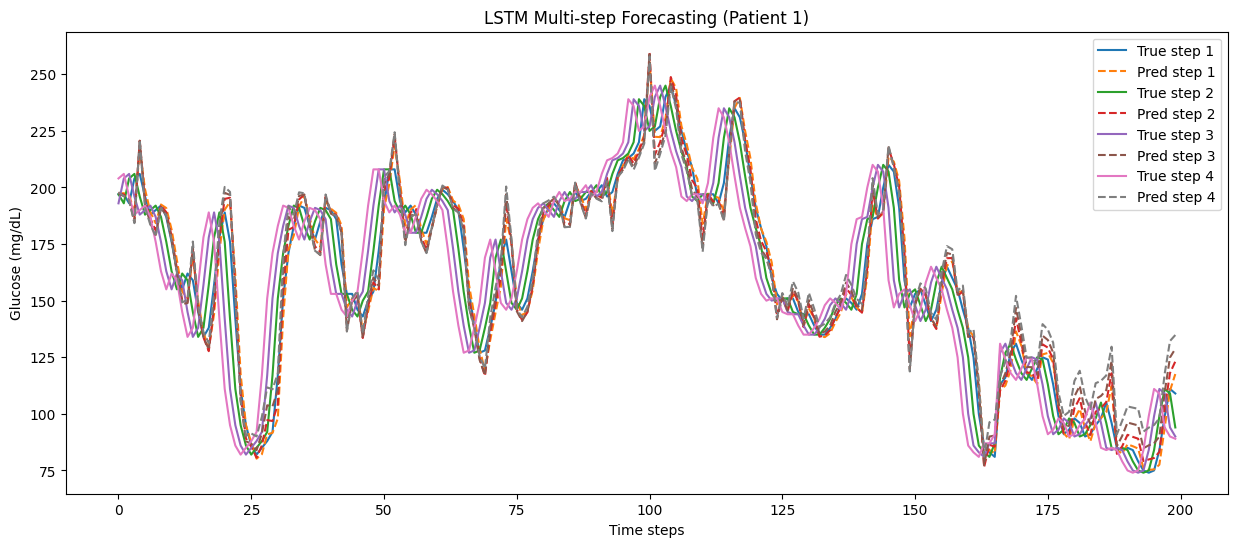

In [13]:
import matplotlib.pyplot as plt

n_plot = 200  # number of timesteps to plot
n_steps = y_real.shape[1]

plt.figure(figsize=(15,6))

for step in range(n_steps):
    plt.plot(y_real[:n_plot, step], label=f"True step {step+1}")
    plt.plot(y_pred[:n_plot, step], linestyle="--", label=f"Pred step {step+1}")

plt.title("LSTM Multi-step Forecasting (Patient 1)")
plt.xlabel("Time steps")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.show()

In [17]:
# take ONLY step 1 (15 min ahead)
y_real_15 = y_real[:, 0]
y_pred_15 = y_pred[:, 0]

# RMSE
rmse = np.sqrt(np.mean((y_real_15 - y_pred_15)**2))
print(f"15-min RMSE: {rmse:.2f} mg/dL")

# MAE
mae = np.mean(np.abs(y_real_15 - y_pred_15))
print(f"15-min MAE: {mae:.2f} mg/dL")

# MAPE
mape = np.mean(np.abs((y_real_15 - y_pred_15) / y_real_15)) * 100
print(f"15-min MAPE: {mape:.2f} %")
# Optional: “accuracy-like” interpretation
accuracy = 100 - mape
print(f"Approximate accuracy: {accuracy:.2f} %")

15-min RMSE: 7.54 mg/dL
15-min MAE: 5.51 mg/dL
15-min MAPE: 3.49 %
Approximate accuracy: 96.51 %


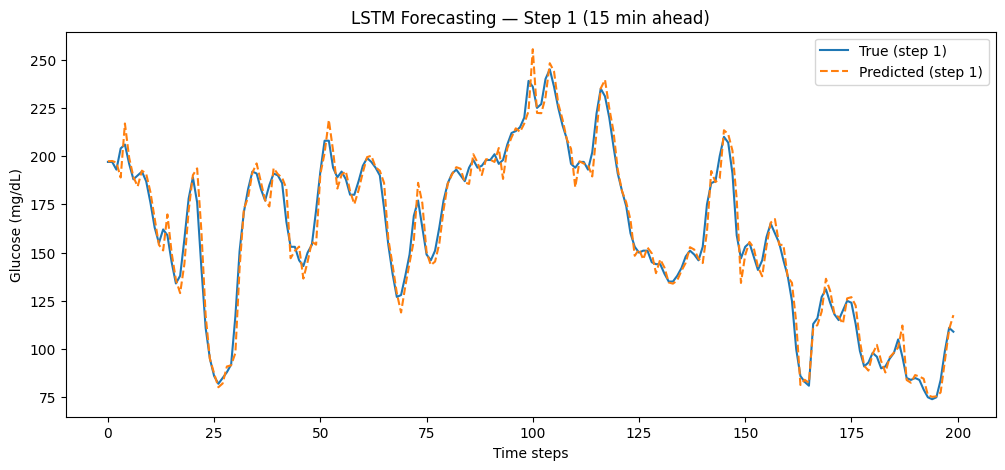

In [19]:
n_plot = 200  # number of timesteps to plot for clarity

plt.figure(figsize=(12,5))
plt.plot(y_real[:n_plot, 0], label="True (step 1)")
plt.plot(y_pred[:n_plot, 0], linestyle="--", label="Predicted (step 1)")
plt.title("LSTM Forecasting — Step 1 (15 min ahead)")
plt.xlabel("Time steps")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.show()